Price Data


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-01,280.425446,496.185883,1591.314331,350.957001,541.725769,196.502716,1283.006348,496.196381,271.551178,1561.000610
2019-01-02,274.413177,491.658478,1576.736206,351.777191,544.984070,195.042969,1268.413574,489.733887,266.384796,1577.817871
2019-01-03,275.159241,487.801025,1580.093750,350.474640,545.065552,193.826569,1241.274536,483.691956,263.846954,1558.662109
2019-01-04,283.014648,489.106018,1574.174072,352.356049,538.467651,195.286316,1235.090576,486.303406,269.783691,1539.711792
2019-01-07,285.208893,489.845245,1577.045410,354.768097,547.142578,195.772842,1231.308960,489.003540,268.560120,1556.980347


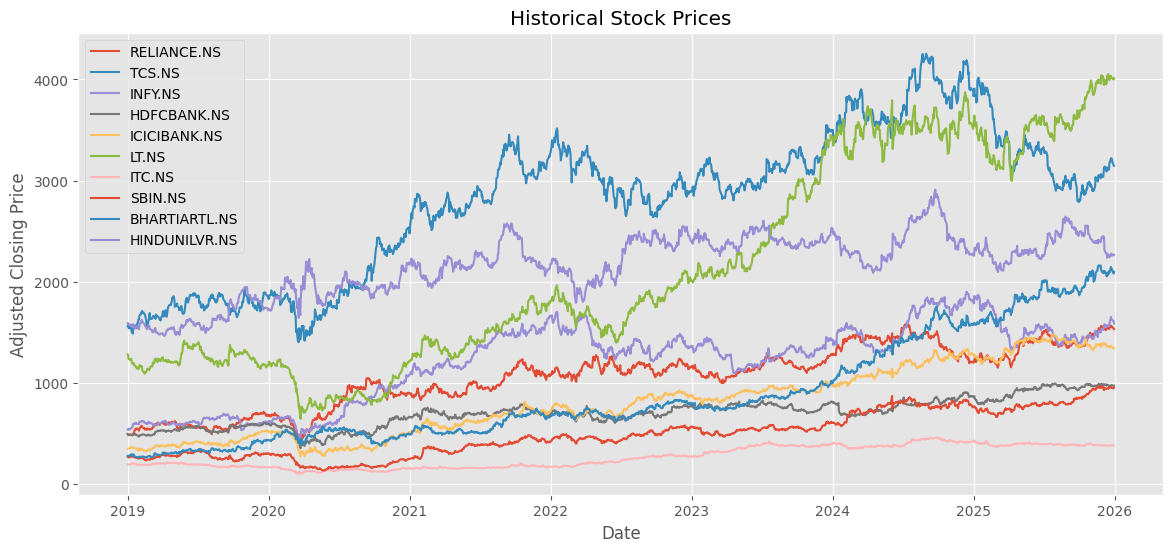

In [5]:

# Mean-Variance Optimization (Maximum Sharpe Portfolio)
# Using 10 Indian Stocks with Yahoo Finance

# Install packages (Run once in Google Colab)
!pip install yfinance scipy --quiet

# ============================================================
# Import Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

plt.style.use("ggplot")

# Select 10 Indian Stocks ============================

stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "LT.NS",
    "ITC.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS"
]

# Download Historical Prices ==========================


prices = yf.download(
    stocks,
    start="2019-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

print("Price Data")
display(prices.head())


# Plot Stock Prices ===========================

plt.figure(figsize=(14,6))

for stock in stocks:
    plt.plot(prices.index, prices[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.show()

In [26]:

# Daily Returns ========================

returns = prices.pct_change().dropna()

print("\nDaily Returns")
display(returns.head())


Daily Returns


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-02,-0.021440,-0.009124,-0.009161,0.002337,0.006015,-0.007429,-0.011374,-0.013024,-0.019025,0.010773
2019-01-03,0.002719,-0.007846,0.002129,-0.003703,0.000150,-0.006237,-0.021396,-0.012337,-0.009527,-0.012141
2019-01-04,0.028549,0.002675,-0.003746,0.005368,-0.012105,0.007531,-0.004982,0.005399,0.022501,-0.012158
2019-01-07,0.007753,0.001511,0.001824,0.006845,0.016110,0.002491,-0.003062,0.005552,-0.004535,0.011215
2019-01-08,0.013233,-0.008323,-0.007900,0.033859,-0.002456,0.009231,-0.001156,-0.000091,0.030374,-0.002292


In [28]:
# Annual Expected Returns =================================

expected_returns = returns.mean() * 252

print("\nExpected Annual Returns")
display(expected_returns)



Expected Annual Returns


,0
Ticker,
BHARTIARTL.NS,0.334275
HDFCBANK.NS,0.129592
HINDUNILVR.NS,0.076848
ICICIBANK.NS,0.239502
INFY.NS,0.194723
ITC.NS,0.125690
LT.NS,0.203842
RELIANCE.NS,0.203808
SBIN.NS,0.233600


In [30]:

# Annual Covariance Matrix =================================

cov_matrix = returns.cov() * 252

print("\nAnnual Covariance Matrix")
display(cov_matrix)



Annual Covariance Matrix


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Ticker,,,,,,,,,,
BHARTIARTL.NS,0.081451,0.022382,0.013425,0.028563,0.020408,0.017253,0.025857,0.024166,0.029850,0.016353
HDFCBANK.NS,0.022382,0.062115,0.014225,0.045558,0.020656,0.017685,0.033575,0.029212,0.039622,0.015814
HINDUNILVR.NS,0.013425,0.014225,0.050920,0.016250,0.016792,0.015331,0.014454,0.018647,0.013055,0.015071
ICICIBANK.NS,0.028563,0.045558,0.016250,0.087173,0.024364,0.023199,0.041932,0.033481,0.059817,0.019170
INFY.NS,0.020408,0.020656,0.016792,0.024364,0.075463,0.013208,0.022302,0.023481,0.020793,0.042447
ITC.NS,0.017253,0.017685,0.015331,0.023199,0.013208,0.057250,0.022432,0.019221,0.029307,0.012342
LT.NS,0.025857,0.033575,0.014454,0.041932,0.022302,0.022432,0.074637,0.029971,0.046223,0.018268
RELIANCE.NS,0.024166,0.029212,0.018647,0.033481,0.023481,0.019221,0.029971,0.078935,0.036133,0.022850
SBIN.NS,0.029850,0.039622,0.013055,0.059817,0.020793,0.029307,0.046223,0.036133,0.099615,0.017634


In [35]:

# Portfolio Return Function ======================

def portfolio_return(weights):
    return np.dot(weights, expected_returns)


# Portfolio Volatility Function ======================

def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

# Negative Sharpe Ratio ======================

risk_free_rate = 0.06      # 6%

def negative_sharpe(weights):

    ret = portfolio_return(weights)

    vol = portfolio_volatility(weights)

    sharpe = (ret - risk_free_rate) / vol

    return -sharpe

# Optimization Setup ======================

n_assets = len(stocks)

initial_weights = np.ones(n_assets) / n_assets

constraints = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

bounds = tuple((0,1) for _ in range(n_assets))

# Run Optimization ======================

result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights = result.x


# Portfolio Allocation ======================


portfolio = pd.DataFrame({
    "Stock": stocks,
    "Weight": weights
})

portfolio["Weight (%)"] = portfolio["Weight"] * 100

portfolio = portfolio.sort_values(
    by="Weight",
    ascending=False
)

print("\nOptimal Portfolio Allocation")
display(portfolio)


Optimal Portfolio Allocation


,Stock,Weight,Weight (%)
0,RELIANCE.NS,5.820861e-01,5.820861e+01
3,HDFCBANK.NS,1.313829e-01,1.313829e+01
4,ICICIBANK.NS,1.304032e-01,1.304032e+01
7,SBIN.NS,7.949639e-02,7.949639e+00
8,BHARTIARTL.NS,4.267146e-02,4.267146e+00
6,ITC.NS,3.396000e-02,3.396000e+00
9,HINDUNILVR.NS,6.986739e-17,6.986739e-15
2,INFY.NS,2.410330e-17,2.410330e-15
5,LT.NS,2.063065e-17,2.063065e-15
1,TCS.NS,0.000000e+00,0.000000e+00


In [44]:

# Portfolio Statistics ===================

final_return = portfolio_return(weights)

final_volatility = portfolio_volatility(weights)

final_sharpe = (
    final_return - risk_free_rate
) / final_volatility

print("OPTIMAL PORTFOLIO PERFORMANCE")
print("="*80)
print(f"Expected Annual Return : {final_return:.2%}")
print(f"Annual Volatility      : {final_volatility:.2%}")
print(f"Sharpe Ratio           : {final_sharpe:.3f}")



OPTIMAL PORTFOLIO PERFORMANCE
Expected Annual Return : 28.45%
Annual Volatility      : 21.77%
Sharpe Ratio           : 1.031


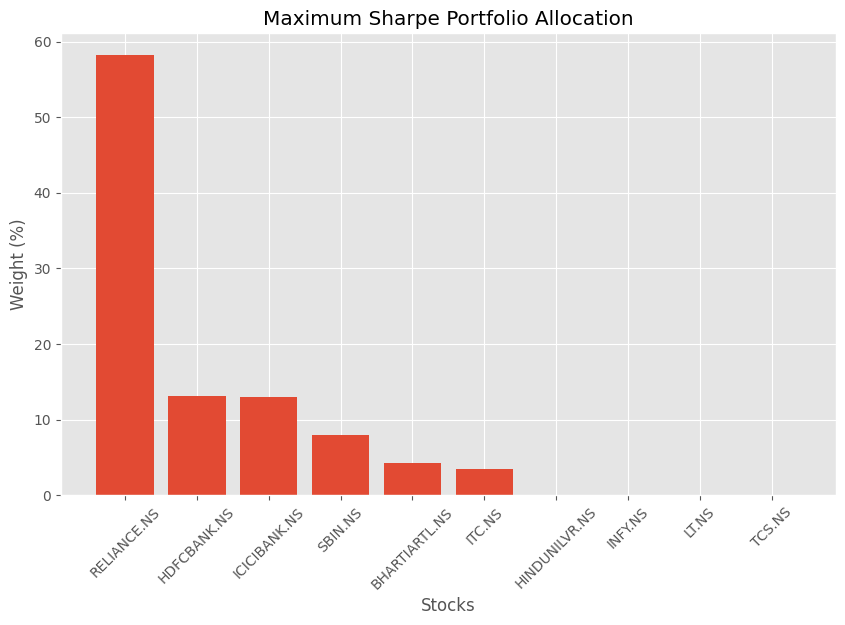

In [20]:
# Plot Portfolio Allocation ==========================


plt.figure(figsize=(10,6))

plt.bar(
    portfolio["Stock"],
    portfolio["Weight (%)"]
)

plt.title("Maximum Sharpe Portfolio Allocation")
plt.xlabel("Stocks")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45)

plt.show()

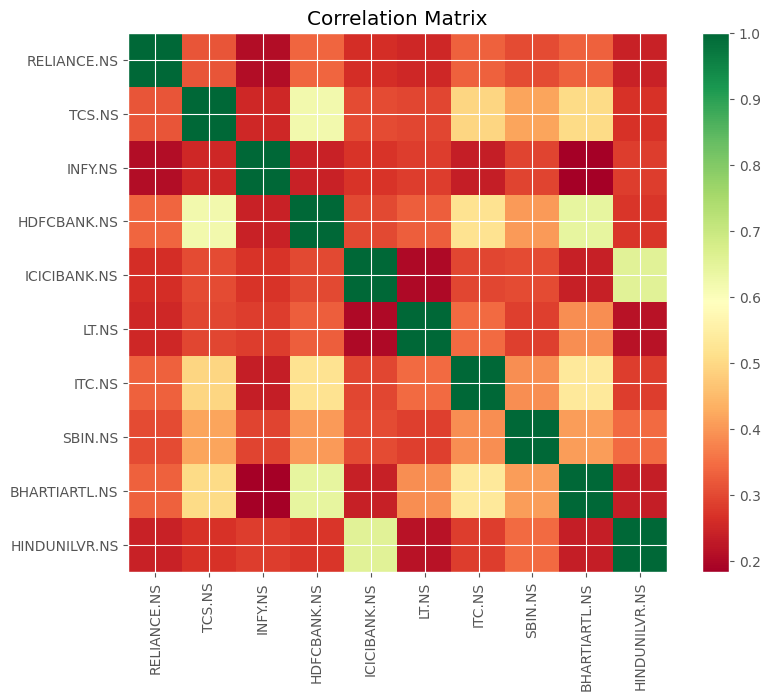

In [49]:
# Correlation Matrix ==========================

corr = returns.corr()

plt.figure(figsize=(9,7))

plt.imshow(corr, cmap="RdYlGn", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(stocks)),
    stocks,
    rotation=90
)

plt.yticks(
    range(len(stocks)),
    stocks
)

plt.title("Correlation Matrix")

plt.show()

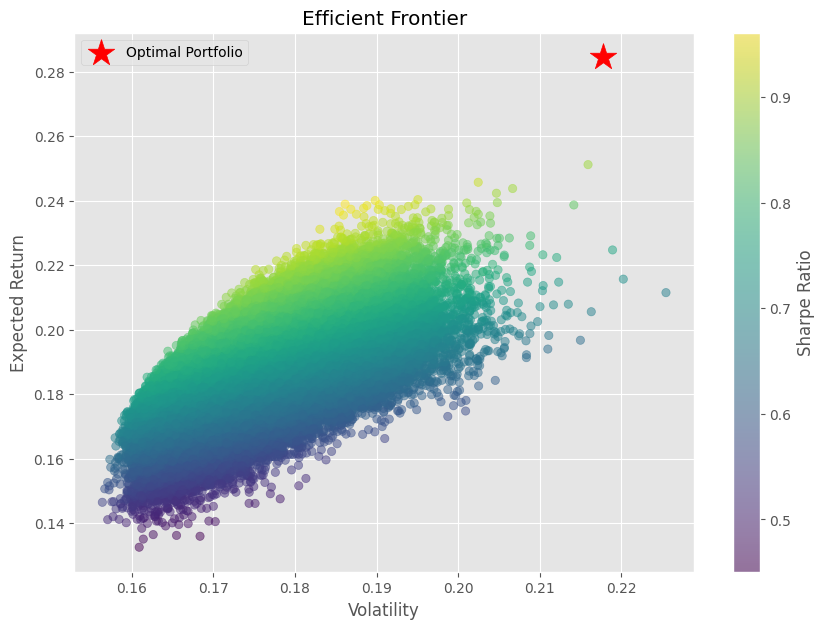

In [52]:
# Efficient Frontier (Monte Carlo Simulation) ==========================


n_portfolios = 100000

results = np.zeros((3, n_portfolios))

all_weights = []

for i in range(n_portfolios):

    w = np.random.random(n_assets)
    w /= np.sum(w)

    all_weights.append(w)

    ret = np.dot(w, expected_returns)

    vol = np.sqrt(
        np.dot(
            w.T,
            np.dot(cov_matrix, w)
        )
    )

    sharpe = (ret - risk_free_rate) / vol

    results[0, i] = vol
    results[1, i] = ret
    results[2, i] = sharpe

    # Plot Efficient Frontier ==========================

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    results[0],
    results[1],
    c=results[2],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    final_volatility,
    final_return,
    color="red",
    marker="*",
    s=400,
    label="Optimal Portfolio"
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")

plt.legend()
plt.show()